In [11]:
import os
os.chdir( os.path.join( os.environ["VSC_DATA"], "physioex" ) )

VSC_DATA = os.environ["VSC_DATA"]
DATA_FOLDER = os.path.join( os.environ["VSC_SCRATCH_PROJECTS_BASE"], "2024_111", "guido" )

import sys
sys.path.append(
    os.path.join(VSC_DATA, "physioex", "articles", "protosleepnet", "scripts", "src")
)

from staging_util import GroupDataset
from group_classification import GroupModule

from physioex.data import PhysioExDataModule
from physioex.train.models import load_model

from tqdm import tqdm
import pandas as pd

import numpy as np
import torch.nn as nn
import torch

import pytorch_lightning as pl


from pytorch_lightning.loggers import CSVLogger, TensorBoardLogger

import torch.optim as optim
import torchmetrics as tm

pl.seed_everything(42)

#GROUP = "alzheimers"

GROUP = "parkinsons"

num_folds = 4

#encoder_name = "protosleeptransformer"
#encoder_class = "physioex.train.networks.protosleeptransformer:ProtoSleepTransformerNet"

encoder_name = "protoseqsleepnet"
encoder_class = "physioex.train.networks.protoseqsleepnet:ProtoSeqSleepNet"

[rank: 0] Seed set to 42


In [12]:
# plotting utils 
from matplotlib import pyplot as plt

try:
    plt.style.use("seaborn-v0_8-paper")
except:
    print("Error: one of the styles is not available")
    print(plt.style.available)
    exit(1)
    
tex_fonts = {
    # Use LaTeX to write all text
    #"text.usetex": True,
    "font.family": "serif",
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 10,
    "font.size": 10,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
}

plt.rcParams.update(tex_fonts)

# column paper size 252.0pt
# use golden ratio for height

width = 252.0 / 72.0  # convert from points to inches
height  = width 

figsize = (width, height)


## Compute cross-fold (4) performances of the models for both nights-subjects levels

In [13]:
# sklearn metrics for binary Heatlhy vs Unhealthy classification
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

In [14]:
gd = GroupDataset(
    datasets=[GROUP],
    data_folder=DATA_FOLDER,
    preprocessing="xsleepnet",
    selected_channels=["EEG", "EOG", "EMG"],
    sequence_length=21,
)

gd.set_num_folds(num_folds)

model_kwargs = {"in_channels": 3, "sequence_length": 21, "weights": [0.75, 0.25]}

results = []
preds = []

for FOLD in range(num_folds):
    print(f"Fold {FOLD + 1} of {num_folds}")
    
    datamodule = PhysioExDataModule(
        datasets=gd,
        batch_size=1,
        folds=FOLD,
        num_workers=18,
    )

    ckpt_path = f"articles/protosleepnet/models/debug/{encoder_name}/group/{GROUP}/staging/fold={FOLD}/"
    # list files inside
    files = [f for f in os.listdir(ckpt_path) if f.endswith(".ckpt")][0]
    ckpt_path = os.path.join(ckpt_path, files)

    encoder = load_model(
        model=encoder_class,
        model_kwargs=model_kwargs,
        ckpt_path=ckpt_path,
        device="cpu",
        softmax=False,
        summary=False,
    ).eval()

    ckpt_path = f"articles/protosleepnet/models/debug/{encoder_name}/group/{GROUP}/groups/fold={FOLD}/"
    # list files inside
    files = [f for f in os.listdir(ckpt_path) if f.endswith(".ckpt")][0]
    ckpt_path = os.path.join(ckpt_path, files)

    model = GroupModule.load_from_checkpoint(
        ckpt_path,
        encoder=encoder,
        input_size=128,  # Assuming the input feature size is 128
        hidden_size=128,  # Size of the hidden state
        num_layers=4,  # Number of LSTM layers
        attention_size=64,  # Size of the attention layer
    ).eval()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    with torch.no_grad():

        nights_preds, nights_labels = [], []
        subjects_preds, subjects_labels = [], []

        for batch in tqdm(datamodule.test_dataloader()):
            x, _, y, _ = batch
            night_length = x.shape[1]
            
            x = x.to(device)
            y_hat = torch.zeros(1, night_length - 21 + 1, 2, dtype=x.dtype, device=x.device)
            for i in range(night_length - 21 + 1):
                x_slice = x[:, i : i + 21, :, :, :]
                y_hat[:, i, :] += model(x_slice.to(device))

            y_hat = torch.nn.functional.softmax(y_hat.reshape(-1, 2), dim=-1).cpu()  # T, C
            y = y.reshape(-1) * torch.ones_like(
                y_hat[:, 0], dtype=y.dtype, device=y.device
            )

            nights_preds.append(y_hat.numpy())
            nights_labels.append(y.numpy())

            # For subject-level predictions, we take the mean of the night predictions
            subject_y_hat = y_hat.mean(dim=0).reshape(1, 2)
            subject_y = y[0].reshape(1)

            subjects_preds.append(subject_y_hat.numpy())
            subjects_labels.append(subject_y.numpy())

        model = model.cpu()

    nights_preds = np.concatenate(nights_preds, axis=0)
    nights_labels = np.concatenate(nights_labels, axis=0)
    subjects_preds = np.concatenate(subjects_preds, axis=0)
    subjects_labels = np.concatenate(subjects_labels, axis=0)

    res = {}
    res["fold"] = FOLD

    res["nights_acc"] = accuracy_score(nights_labels, np.argmax(nights_preds, axis=1))
    res["nights_f1"] = f1_score(nights_labels, np.argmax(nights_preds, axis=1), average="weighted")
    res["nights_precision"] = precision_score(nights_labels, np.argmax(nights_preds, axis=1), average="weighted")
    res["nights_recall"] = recall_score(nights_labels, np.argmax(nights_preds, axis=1), average="weighted")
    
    res["subjects_acc"] = accuracy_score(subjects_labels, np.argmax(subjects_preds, axis=1))
    res["subjects_f1"] = f1_score(subjects_labels, np.argmax(subjects_preds, axis=1), average="weighted")
    res["subjects_precision"] = precision_score(subjects_labels, np.argmax(subjects_preds, axis=1), average="weighted")
    res["subjects_recall"] = recall_score(subjects_labels, np.argmax(subjects_preds, axis=1), average="weighted")
    
    preds.append({
        "fold": FOLD,
        "nights_preds": nights_preds,
        "nights_labels": nights_labels,
        "subjects_preds": subjects_preds,
        "subjects_labels": subjects_labels,
    })

    results.append(res)

# convert the results to a DataFrame
results_df = pd.DataFrame(results)
results_df.to_csv(f"articles/protosleepnet/models/debug/{encoder_name}/group/{GROUP}/groups/results.csv", index=False)
results_df.mean()


2025-07-06 14:25:05.576 | WARNING  | physioex.data.datareader:__init__:68 - Sequence length 86400 is greater than the max number of windows 1338 for dataset parkinsons/night/HOA.
Loading healthy dataset: 100%|██████████| 40/40 [00:18<00:00,  2.14it/s]
2025-07-06 14:25:24.297 | WARNING  | physioex.data.datareader:__init__:68 - Sequence length 86400 is greater than the max number of windows 1452 for dataset parkinsons/night/PD.
Loading unhealthy dataset: 100%|██████████| 86/86 [00:42<00:00,  2.01it/s]
2025-07-06 14:26:07.056 | WARNING  | physioex.data.datamodule:__init__:54 - The usage of PhysioExDataset as datasets is deprecated. Please use a list of dataset names instead.


Fold 1 of 4


Splitting test set into sequences: 100%|██████████| 32/32 [00:00<00:00, 175.98it/s]


Dataset split into 79732 train, 19 valid, and 32 test sequences.


/data/leuven/365/vsc36564/miniconda3/envs/physioex/lib/python3.12/site-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.5.1.post0, which is newer than your current Lightning version: v2.5.0.post0
/data/leuven/365/vsc36564/miniconda3/envs/physioex/lib/python3.12/site-packages/pytorch_lightning/utilities/parsing.py:209: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


...

Dataset split into 81146 train, 19 valid, and 31 test sequences.


/data/leuven/365/vsc36564/miniconda3/envs/physioex/lib/python3.12/site-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.5.1.post0, which is newer than your current Lightning version: v2.5.0.post0
/data/leuven/365/vsc36564/miniconda3/envs/physioex/lib/python3.12/site-packages/pytorch_lightning/utilities/parsing.py:209: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


Channel mixing weights : [0.75, 0.25]


/data/leuven/365/vsc36564/miniconda3/envs/physioex/lib/python3.12/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 18 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 31/31 [03:13<00:00,  6.25s/it]
/data/leuven/365/vsc36564/miniconda3/envs/physioex/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/data/leuven/365/vsc36564/miniconda3/envs/physioex/lib/python3.12/site-packages/sklearn/metrics/_cl

fold                  1.500000
nights_acc            0.680056
nights_f1             0.550553
nights_precision      0.462487
nights_recall         0.680056
subjects_acc          0.682460
subjects_f1           0.553666
subjects_precision    0.465777
subjects_recall       0.682460
dtype: float64

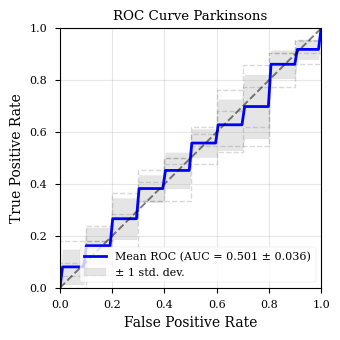

In [15]:
# plot the ROC curve for both nights and subjects for all the folds ( all the folds curves in the same plot )
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, roc_curve, auc
import numpy as np

# update the code to make a single plot for both nights and subjects ( subplot 1 row  2 columns )
fig, axs = plt.subplots(1, 1, figsize=figsize, sharex=True, sharey=True)

# Common FPR grid for interpolation
mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []

# Plot individual fold curves with same color and dashed lines
for i, fold_data in enumerate(preds):
    subjects_preds = fold_data["subjects_preds"]
    subjects_labels = fold_data["subjects_labels"]
    
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(subjects_labels, subjects_preds[:, 1])
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    # Interpolate TPR values at common FPR points
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    
    # Plot individual curves
    axs.plot(fpr, tpr, 
             color='gray', 
             alpha=0.3, 
             linestyle='--',
             linewidth=1)

# Calculate mean and std
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

# Plot mean curve
axs.plot(mean_fpr, mean_tpr, 
         color='blue',
         linewidth=2,
         label=f'Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})')

# Plot confidence interval
axs.fill_between(mean_fpr, tprs_lower, tprs_upper, 
                 color='gray', alpha=0.2, 
                 label='± 1 std. dev.')

# Plot diagonal line
axs.plot([0, 1], [0, 1], 'k--', alpha=0.5)

axs.set_title(f"ROC Curve {GROUP.capitalize()}")
axs.legend(loc="lower right")
axs.set_xlabel("False Positive Rate")
axs.set_ylabel("True Positive Rate")
axs.set_xlim([0.0, 1.0])
axs.set_ylim([0.0, 1.0])

axs.grid(True, alpha=0.3)

plt.tight_layout()

filename = f"{GROUP}-{encoder_name}-roc-curves"

fig.savefig( f"articles/protosleepnet/results/{filename}.pdf", format='pdf', bbox_inches='tight')